In [1]:
import sys

sys.path.append("..")

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from dataset.cyclone import CycloneDataset

In [3]:
dataset = CycloneDataset(
    path="/restricteddata/ukaea/gyrokinetics/preprocessed",
    split="train",
    normalization=None,
    spatial_ifft=True,
    input_fields=["df", "phi"],
    trajectories=["iteration_24.h5"],
)

## Main figure: simple 2d

In [ ]:
gt_t = []
for t in [0, 30, 60, 80, 100, 120, 150]:
    sample = dataset[t]
    gt = sample.y_df
    gt_t.append(gt)

In [ ]:
def force_aspect(ax, aspect=1):
    im = ax.get_images()
    extent = im[0].get_extent()
    ax.set_aspect(abs((extent[1] - extent[0]) / (extent[3] - extent[2])) / aspect)


selected_comb = [(0, 2), (2, 3), (0, 3), (3, 4)]

fig, ax = plt.subplots(len(gt_t), 4, figsize=(8, 16), facecolor="none", dpi=100)
fig.subplots_adjust(hspace=0.05, wspace=0.05)

for t in range(len(gt_t)):
    for k in range(4):
        ax_ij = ax[t, k]
        ax_ij.set_frame_on(False)
        ax_ij.tick_params(labelleft=False, labelbottom=False)
        ax_ij.set_xticks([])
        ax_ij.set_yticks([])

c_map = matplotlib.colormaps["RdBu"]
c_map.set_bad("k")

for t in range(len(gt_t)):
    x1 = gt_t[t]
    for k, (i, j) in enumerate(selected_comb):
        other = tuple([o for o in range(5) if o != i and o != j])

        x1_plot = x1[0].mean(other)

        ax1 = ax[t, k]

        # compute shared vmin and vmax
        vmin = x1_plot.min()
        vmax = x1_plot.max()

        # Plot x1 and xp side by side
        ax1.matshow(x1_plot, cmap=c_map, vmin=vmin, vmax=vmax)

        # Remove axis ticks and labels
        ax1.set_xticks([])
        ax1.set_yticks([])
        ax1.tick_params(labelleft=False, labelbottom=False)
        # Force aspect ratio
        force_aspect(ax1)

fig.savefig("figs/dft.svg", bbox_inches="tight")

## Flux trace

In [ ]:
import os

directory = "/restricteddata/ukaea/gyrokinetics/raw/iteration_36"
ST = 0
time = np.loadtxt(os.path.join(directory, "time.dat"))
fluxes = np.loadtxt(os.path.join(directory, "fluxes.dat"))

fig, ax = plt.subplots(1, 1, figsize=(8, 3), facecolor="none", dpi=100)
ax.plot(time[ST:400], fluxes[ST:400, 1], lw=5, c="#E0785F")
ax.plot(
    time[200:400], [fluxes[200:400, 1].mean()] * 200, lw=4, c="#AAA85F", linestyle="--"
)
# ax.set_xlabel(r"$t$", fontsize=20)
# ax.set_ylabel(r"$\int \delta f$", fontsize=20)
ax.set_xticks([])
ax.set_yticks([])
fig.savefig("figs/fluxes.svg", bbox_inches="tight")

In [ ]:
import os

directory = "/restricteddata/ukaea/gyrokinetics/raw/iteration_24"
time = np.loadtxt(os.path.join(directory, "time.dat"))
fluxes = np.loadtxt(os.path.join(directory, "fluxes.dat"))


fig, ax = plt.subplots(1, 1, figsize=(8, 3), facecolor="none", dpi=100)
ax.plot(time[80:400], fluxes[80:400, 2], lw=3, c=(32 / 255, 70 / 255, 125 / 255))
# ax.set_xlabel(r"$t$", fontsize=20)
# ax.set_ylabel(r"$\int \delta f$", fontsize=20)
ax.set_xticks([])
ax.set_yticks([])
fig.savefig("figs/fluxes.svg", bbox_inches="tight")

In [ ]:
import matplotlib.pyplot as plt
import os

plt.rcParams.update(
    {
        "text.usetex": True,
        "font.family": "serif",
        "pgf.rcfonts": False,
    }
)

latex_table = r"""
\begin{tabular}{lllll}
$\hat{s}$ & ITG  & ... & $\bar{Q}$ &  \\
4.5       & 7.5  &     & 17.2      &  \\
4.2       & 5.5  &     & 1.3       &  \\
          &      &     & $\vdots$  &  \\
5.6       & 12.8 &     & 132.4     & 
\end{tabular}
"""

fig, ax = plt.subplots(figsize=(4, 2))
ax.text(0.5, 0.5, latex_table, size=12, va="center", ha="center", wrap=True)

## Poteltial plots

In [ ]:
from matplotlib import colormaps


# Plot real space potential
fig, ax = plt.subplots(3, 1, figsize=(12, 6))

c_map = colormaps["plasma"]

fig.subplots_adjust(hspace=0.05)

ax[0].matshow(np.squeeze(dataset[5].y_phi.sum(0)[:, 7, :]).T, cmap=c_map)
ax[0].set_xticks([])
ax[0].set_yticks([])

ax[1].matshow(np.squeeze(dataset[60].y_phi.sum(0)[:, 7, :]).T, cmap=c_map)
# ax[1].set_ylabel(r"$y_{\phi}$", fontsize=20)
ax[1].set_xticks([])
ax[1].set_yticks([])

ax[2].matshow(np.squeeze(dataset[120].y_phi.sum(0)[:, 7, :]).T, cmap=c_map)
# ax[2].set_xlabel(r"$x_{\phi}$", fontsize=20)
ax[2].set_xticks([])
ax[2].set_yticks([])

fig.savefig("figs/potentials.svg", bbox_inches="tight")

In [ ]:
from matplotlib import colormaps


# Plot real space potential
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

c_map = colormaps["plasma"]

fig.subplots_adjust(hspace=0.05)

ax.matshow(np.squeeze(dataset[120].y_phi.sum(0)[:, 7, :]).T, cmap=c_map)
ax.set_xticks([])
ax.set_yticks([])

fig.savefig("figs/potentials.svg", bbox_inches="tight")

In [ ]:
from matplotlib import colormaps
import matplotlib.pyplot as plt
import numpy as np

phi = dataset[120].y_phi.sum(0)
n_slices = phi.shape[1]

num_surfaces = 8
selected_slices = np.linspace(0, n_slices - 1, num=num_surfaces, dtype=int)

fig = plt.figure(figsize=(12, 8), facecolor="none", dpi=100)
ax = fig.add_subplot(111, projection="3d", facecolor="none")
c_map = colormaps["plasma"]

for k, y_slice in enumerate(selected_slices):
    slice_data = phi[:, y_slice, :].T

    x = np.arange(slice_data.shape[1])
    z = np.arange(slice_data.shape[0])
    X, Z = np.meshgrid(x, z)

    Y = np.full_like(X, y_slice)

    ax.plot_surface(
        X,
        Y,
        Z,
        facecolors=c_map(plt.Normalize(phi.min(), phi.max())(slice_data)),
        cmap=c_map,
        alpha=1.0 * (1 - (0.7 * 1 / len(selected_slices)) * (len(selected_slices) - k)),
        antialiased=True,
        linewidth=0,
    )

ax.set_axis_off()
ax.grid(False)

ax.view_init(elev=25, azim=-45)

fig.savefig("figs/3d_multislice_potentials.png", bbox_inches="tight")

## vspace plane

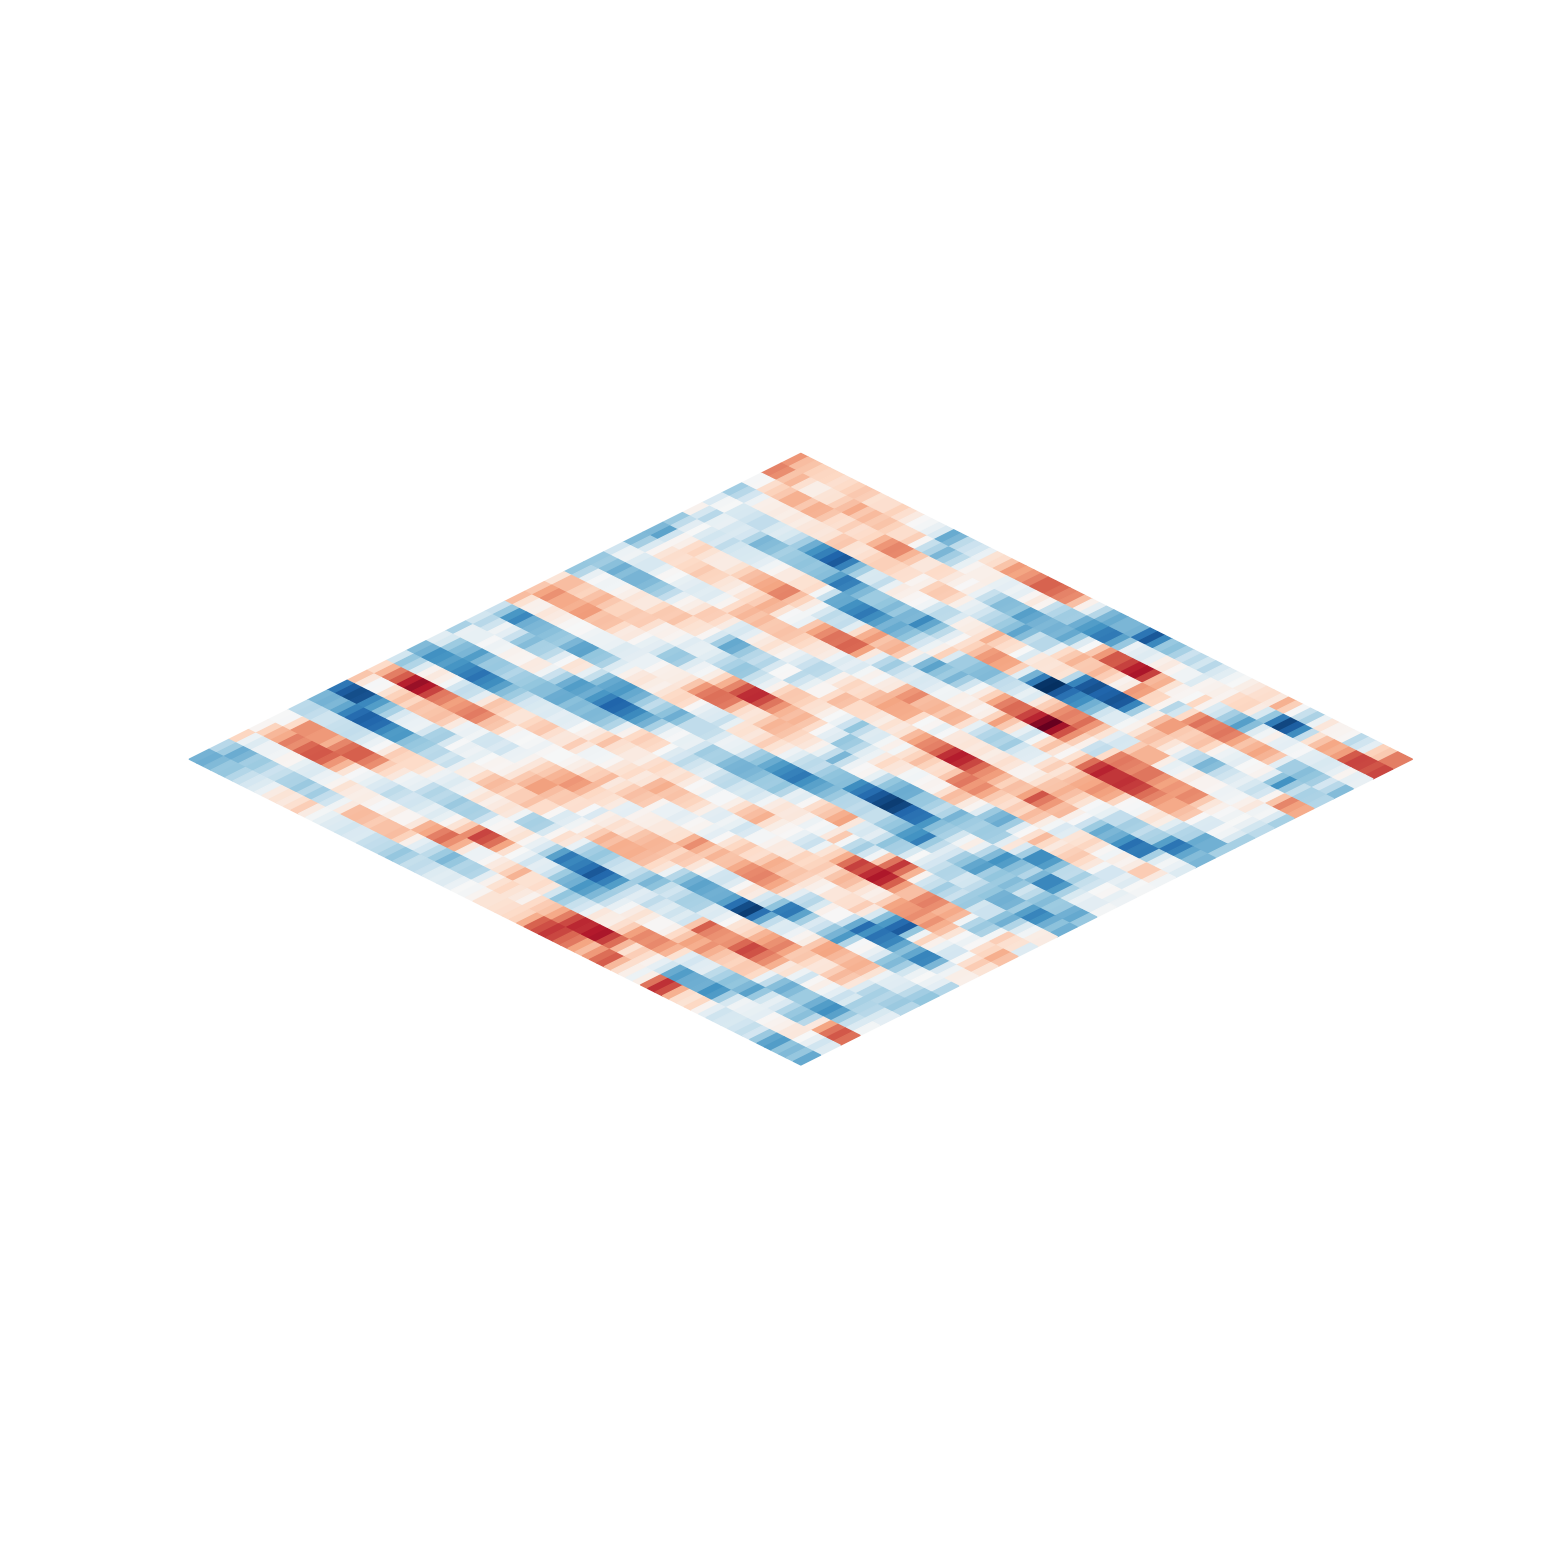

In [28]:
def plot2D_ortho(
    x,
    fixed_axes=(2, 3),
    subs_2d=(1, 1),
    cmap="RdBu_r",
    vmin=None,
    vmax=None,
    elev=30,
    azim=-45,
):
    slice_axes = [i for i in range(5) if i not in fixed_axes]
    if hasattr(x, "numpy"):
        x = x.numpy()

    projection = np.mean(x, axis=tuple(slice_axes))

    fig = plt.figure(figsize=(20, 20), facecolor="none", dpi=100)
    ax = fig.add_subplot(111, projection="3d", facecolor="none")
    ax.set_proj_type("ortho")
    ax.view_init(elev=elev, azim=azim)

    X, Y = np.meshgrid(
        np.arange(0, projection.shape[0]),
        np.arange(0, projection.shape[1]),
        indexing="ij",
    )
    norm = matplotlib.colors.Normalize(
        vmin=projection[:: subs_2d[0], :: subs_2d[1]].min() if vmin is None else vmin,
        vmax=projection[:: subs_2d[0], :: subs_2d[1]].max() if vmax is None else vmax,
    )

    ax.plot_surface(
        X,
        Y,
        np.zeros_like(projection),
        facecolors=plt.get_cmap(cmap)(norm(projection)),
        shade=False,
        rstride=subs_2d[0],
        cstride=subs_2d[1],
    )

    ax.set_axis_off()
    return fig


x = dataset[120].df.numpy().sum(0)

fig = plot2D_ortho(x, fixed_axes=(3, 4), subs_2d=(1, 1))
fig.savefig("figs/vspace.png", bbox_inches="tight")

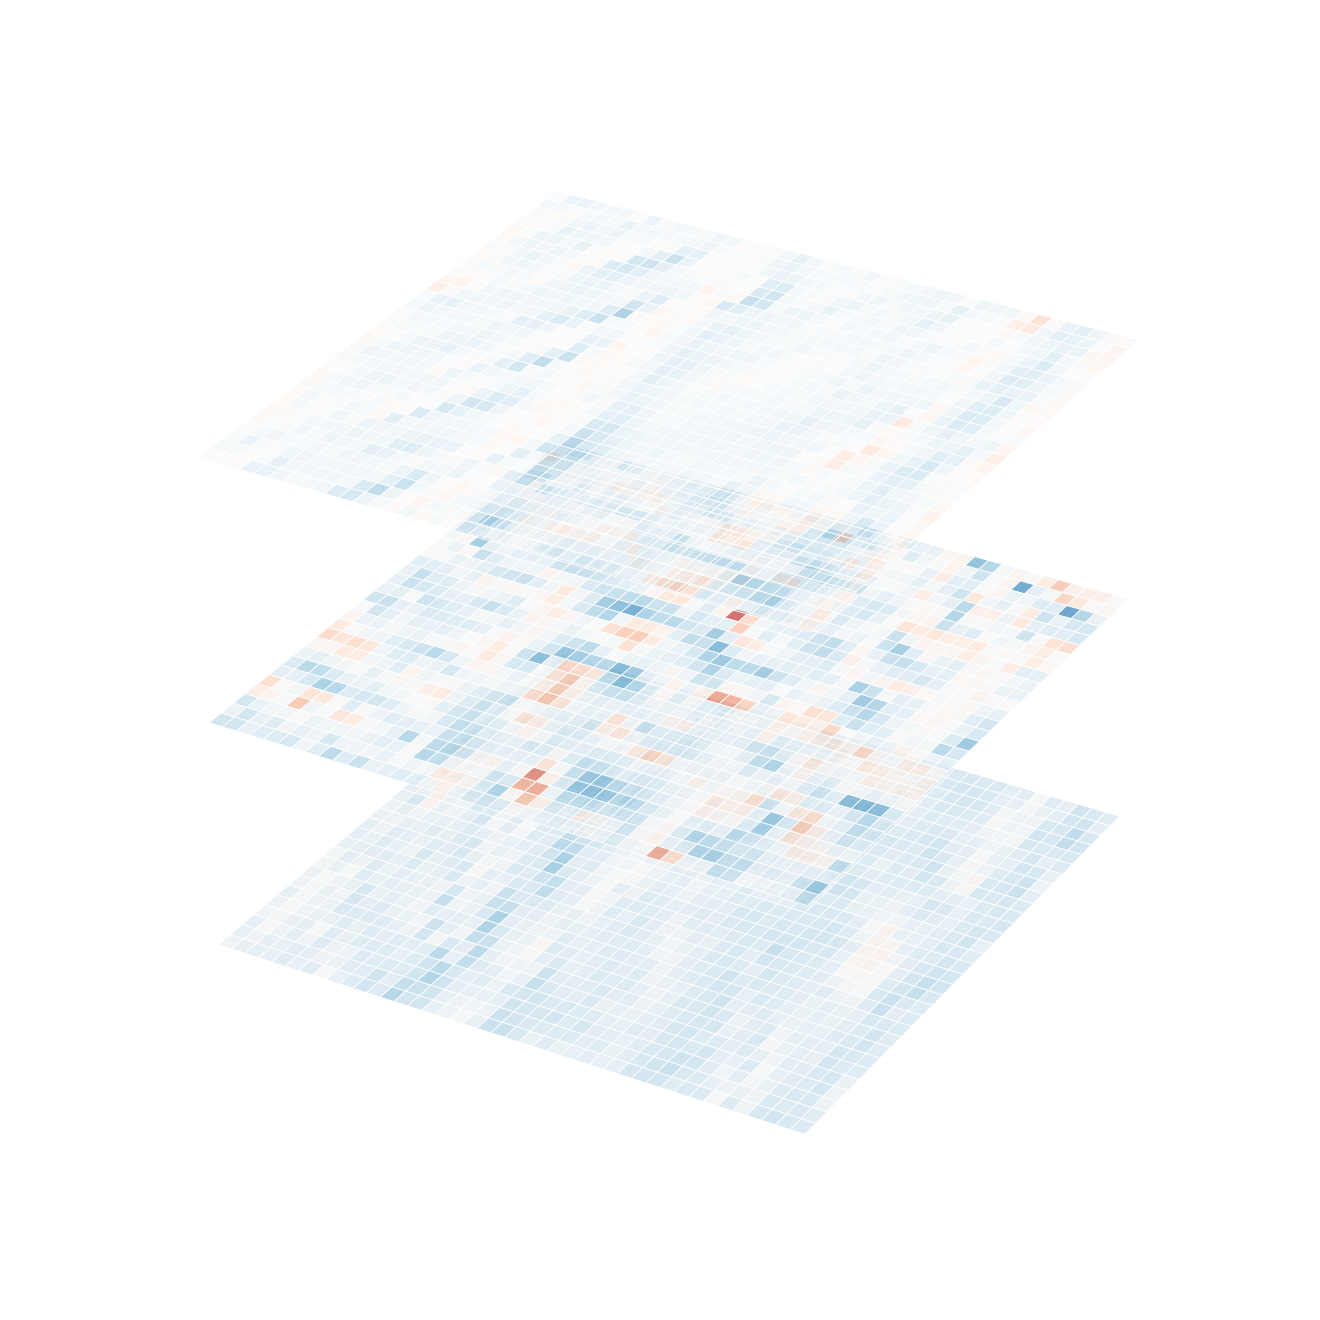

In [31]:
from einops import rearrange


def plot3D(
    x,
    axes_3d=(3, 4, 2),
    title="",
    subs_2d=(1, 1),
    subs_3d=(1, 1, 1),
    alpha=1.0,
    cmap="RdBu_r",
    bg_alpha=0.0,
    facecolor=None,
    surface_slices=None,  # Number of Z-slices to show as surfaces
    edgecolor="white",  # Color of the surface grid lines
    linewidth=0.1,  # Width of the grid lines
    select_idx=None,
    dpi=300,
):
    # Validate subsampling parameters
    if len(subs_2d) != 2:
        raise ValueError("subs_2d must be a tuple of length 2")
    if len(subs_3d) != 3:
        raise ValueError("subs_3d must be a tuple of length 3")

    fixed_axis1, fixed_axis2 = tuple([i for i in range(5) if i not in axes_3d])

    # Determine grid size with axis-specific subsampling
    n1, n2 = x.shape[fixed_axis1], x.shape[fixed_axis2]
    plane_indices1 = range(0, n1, subs_2d[0])
    plane_indices2 = range(0, n2, subs_2d[1])

    if select_idx:
        plane_indices1 = [list(plane_indices1)[select_idx[0]]]
        plane_indices2 = [list(plane_indices2)[select_idx[1]]]

    n_rows = len(plane_indices1)
    n_cols = len(plane_indices2)

    fig = plt.figure(
        figsize=(2 * len(plane_indices2), 2 * len(plane_indices1)),
        facecolor="none",
        dpi=dpi,
    )

    # Find global min/max for consistent coloring
    global_min = np.inf
    global_max = -np.inf
    global_mean_min = np.inf
    global_mean_max = -np.inf
    slice_means = []  # Store means for background colors

    for i in plane_indices1:
        for j in plane_indices2:
            idx = [slice(None)] * 5
            idx[fixed_axis1] = i
            idx[fixed_axis2] = j
            xx = x[tuple(idx)]
            global_min = min(global_min, xx.min())
            global_max = max(global_max, xx.max())
            slice_means.append(xx.mean())
            global_mean_min = min(global_mean_min, xx.mean())
            global_mean_max = max(global_mean_max, xx.mean())

    norm = plt.Normalize(global_mean_min, global_mean_max)

    def make_faint_color(mean_val):
        rgba = matplotlib.colormaps[cmap](norm(mean_val))
        return (rgba[0], rgba[1], rgba[2], bg_alpha)

    bg_colors = [make_faint_color(mean) for mean in slice_means]

    # Create a gridspec with no spacing between subplots
    gs = fig.add_gridspec(
        n_rows, n_cols, left=0, right=1, bottom=0, top=1, wspace=0, hspace=0
    )

    # Create all plots
    plot_idx = 0
    for i, row in enumerate(plane_indices1):
        for j, col in enumerate(plane_indices2):
            kwargs = {"facecolor": bg_colors[plot_idx] if facecolor else "none"}
            ax = fig.add_subplot(gs[i, j], projection="3d", alpha=bg_alpha, **kwargs)
            plot_idx += 1

            # Get the data slice
            idx = [slice(None)] * 5
            idx[fixed_axis1] = row
            idx[fixed_axis2] = col
            xx = x[tuple(idx)]
            xx = rearrange(xx, "s x y -> x y s")

            # Subsample the data
            xx = xx[:: subs_3d[0], :: subs_3d[1], :: subs_3d[2]]

            # Create meshgrid for X and Y
            X, Y = np.meshgrid(
                np.arange(0, xx.shape[0]), np.arange(0, xx.shape[1]), indexing="ij"
            )

            # Determine which Z-slices to plot as surfaces
            if surface_slices is None:
                # Default to showing 3 surfaces (min, middle, max)
                z_indices = [0, xx.shape[2] // 2, xx.shape[2] - 1]
            else:
                z_indices = np.linspace(0, xx.shape[2] - 1, surface_slices, dtype=int)

            # Plot each surface with decreasing alpha based on Z position
            for k, z in enumerate(z_indices):
                Z_val = np.full_like(X, z)
                ax.plot_surface(
                    X,
                    Y,
                    Z_val,
                    facecolors=matplotlib.colormaps[cmap](
                        plt.Normalize(global_min, global_max)(xx[:, :, z])
                    ),
                    edgecolor=edgecolor,
                    linewidth=linewidth,
                    alpha=alpha * (1 - 0.3 * k),  # Slightly fade further surfaces
                    shade=False,
                    zorder=z,
                )

            # Remove all axes and frames
            ax.set_axis_off()
            ax.grid(False)

    # Adjust the suptitle position to account for no padding
    fig.subplots_adjust(top=0.95 if title else 1.0)

    return fig


x = dataset[120].df.numpy().sum(0)

fig = plot3D(
    x,
    axes_3d=(3, 4, 2),
    subs_2d=(4, 2),
    subs_3d=(1, 1, 1),
    surface_slices=3,
    select_idx=(-1, 1),
    dpi=600,
)
fig.savefig("figs/vspace_projection.png")